# Predicting content-decline risk for a human review queue

**Author:** Jessica George  
**Lane:** Refresh / Content Opportunity Scoring

This notebook is the reproducible companion to the deployed paper. It asks: **Can safe, pre-decision search signals rank content items by the risk that their average daily impressions will decline later in the same month?** The output supports a human content-review queue, not automatic rewriting or deletion.

## Abstract

This study asks whether safe search-performance signals available by mid-month can help FlyRank content teams decide which content items to review first when attention is limited. I aggregate one row per pseudonymized content item from a 78,835,655-row daily performance table, define the outcome only from the later window, and compare a random forest with a transparent weighted rule. Development uses March 2026, while June 2026 remains a sealed temporal test. On the same June rows, the model improves ROC-AUC from 0.542 to 0.573 and average precision from 0.538 to 0.588, with top-50 precision moving from 0.80 to 0.82. The measured lift supports a human review queue with reason codes; it does not prove causality or justify automated content changes.

## 1. Question

FlyRank's content problem is practical: content teams have more pages than they can inspect carefully. The decision is which content items a content team should inspect first when review time is limited. One row is one pseudonymized content item. The model outputs a decline-risk score and a ranked queue with reason codes. A false positive wastes review time and may encourage an unnecessary edit; a false negative may delay attention to a genuine decline. Because search behavior varies continuously and signals interact, a learned ranking may add value beyond a fixed threshold, but the improvement must be tested against a transparent rule. On the sealed June test, the learned ranking placed 41 observed declines in the first 50 reviews, compared with 40 for the rule: a modest decision-support gain, not a case for automatic editing.

## 2. Data

I used `flyrank_pseudonymized_warehouse_release_v20260703`, specifically `fact_content_daily_performance`: 78,835,655 daily rows spanning 2025-01-27 through 2026-06-30. The analysis reads only March 2026 for development and June 2026 for the sealed temporal test. Features use days 1–15; the outcome uses days 16–month end. Rows with `gsc_data_available IS TRUE` and at least 100 pre-decision impressions are retained. I deliberately exclude client identity as a feature, URLs, queries, product flags, GA4 outcomes, post-decision fields, and raw exports because they are unnecessary, unavailable at scoring time, public-unsafe, or leakage risks.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, SVG

ROOT = Path.cwd()
if not (ROOT / 'work').exists():
    ROOT = ROOT.parent.parent
RESULTS = json.loads((ROOT / 'work/outputs/capstone_results.json').read_text())
pd.DataFrame({
    'window': ['March development', 'June sealed test'],
    'content_rows': [RESULTS['development_rows'], RESULTS['test_rows']],
    'pseudonymous_clients': [RESULTS['development_clients'], RESULTS['test_clients']],
})

,window,content_rows,pseudonymous_clients
0,March development,77540,38
1,June sealed test,79564,45


## 3. Methodology

The target is `declined_post = 1` when average daily impressions after day 15 are below 80% of average daily impressions during days 1–15. The five pre-decision features are impressions, clicks, CTR, average position, and active days. The baseline is a documented weighted score using visibility, position opportunity, activity, and CTR gap. A random forest (300 trees, depth 8, minimum leaf 50, balanced classes, seed 42) learns nonlinear interactions. Both methods are evaluated on exactly the same June rows. The time-aware March→June split keeps the final month out of label development. Leakage checks reject outcome-window columns, target-derived fields, client IDs, and operational flags.

In [2]:
pd.DataFrame({
    'feature': RESULTS['features'],
    'available_when': ['days 1–15 only'] * len(RESULTS['features'])
})

,feature,available_when
0,impressions_pre,days 1–15 only
1,clicks_pre,days 1–15 only
2,ctr_pre,days 1–15 only
3,avg_position_pre,days 1–15 only
4,active_days_pre,days 1–15 only


## 4. Results (model vs baseline on the same split)

The sealed June test contains 79,564 model rows with an observed decline base rate of 0.520. The model produces a modest directional lift—not a perfect prediction system. ROC-AUC rises from about 0.542 to 0.573, average precision from 0.538 to 0.588, and precision among the first 50 reviews from 0.80 to 0.82. That top-50 result corresponds to 41 observed declines for the model queue versus 40 for the baseline queue.

In [3]:
metrics = pd.DataFrame(RESULTS['metrics']).T.rename_axis('method')
display(metrics.style.format({
    'roc_auc': '{:.3f}',
    'average_precision': '{:.3f}',
    'precision_at_50': '{:.2f}',
}))
print('Observed June decline base rate:', f"{RESULTS['test_positive_rate']:.3f}")
print('Same sealed June rows for both methods:', f"{RESULTS['test_rows']:,}")

,roc_auc,average_precision,precision_at_50
method,,,
baseline,0.542,0.538,0.80
model,0.573,0.588,0.82


Observed June decline base rate: 0.520
Same sealed June rows for both methods: 79,564


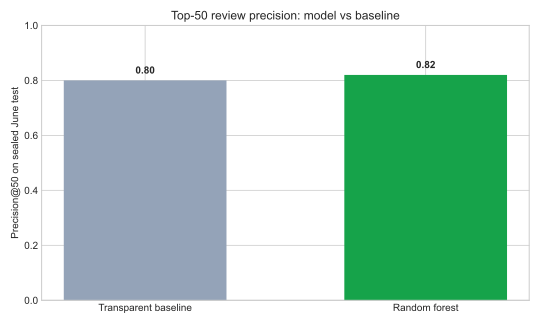

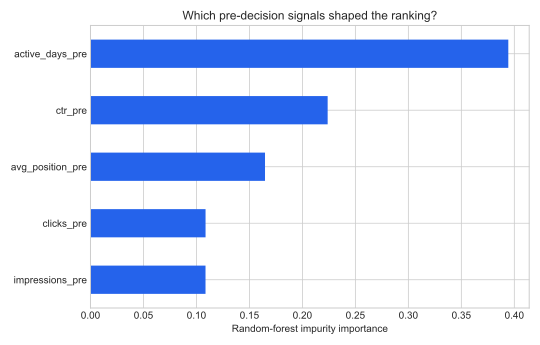

,impurity_importance
pre_decision_feature,
active_days_pre,0.394
ctr_pre,0.224
avg_position_pre,0.165
clicks_pre,0.109
impressions_pre,0.109


In [4]:
display(SVG(filename=str(ROOT / 'docs/assets/capstone_precision.svg')))
display(SVG(filename=str(ROOT / 'docs/assets/capstone_importance.svg')))
importance = (
    pd.Series(RESULTS['feature_importance'], name='impurity_importance')
    .sort_values(ascending=False)
    .rename_axis('pre_decision_feature')
    .to_frame()
)
display(importance.style.format({'impurity_importance': '{:.3f}'}))

## 5. Limitations and honest framing

This is observational decision support. It does not prove that any feature causes search performance, that a refresh will recover impressions, or that Google uses these variables as ranking factors. The label is an operational proxy sensitive to seasonality, demand shifts, measurement noise, and the within-month window. June has more pseudonymous clients than March, and performance may differ across client mixes. Impurity importance is descriptive of this fitted model, not causal importance. A human must inspect search intent, content quality, business context, and recent edits before acting.

## 6. Ranked recommendations

The queue prioritizes review, not automatic intervention. `review_for_refresh_or_protection` means inspect a high-visibility item for factual staleness, intent mismatch, and preservation risk. `review_title_meta_and_intent_match` means visible placement plus low CTR merits snippet and intent review. `monitor_position_and_assess_demand` means weak position makes demand or discoverability a plausible alternative explanation. Every recommendation retains pseudonymous IDs and reason codes.

Before acting, a person must inspect the live page, query and SERP context, seasonality, recent edits, overlap with other pages, business value, risk, and measurement plan. Publishing, rewriting, deleting, pruning, merging, redirects, canonical/indexing changes, and sensitive-content decisions must **not** be automated from this queue.

In [5]:
queue = pd.DataFrame(RESULTS['top_recommendations'])
queue[['rank', 'content_hash_id', 'model_score', 'impressions_pre', 'ctr_pre', 'avg_position_pre', 'reason_codes', 'suggested_action']].head(10)

,rank,content_hash_id,model_score,impressions_pre,ctr_pre,avg_position_pre,reason_codes,suggested_action
0,1,content_9b76202a02885037,0.890187,25943,0.019273,48.689318,high_recent_visibility|persistent_observation|...,review_for_refresh_or_protection
1,2,content_86c96002dd5c69aa,0.888359,12636,0.047483,43.707325,high_recent_visibility|persistent_observation|...,review_for_refresh_or_protection
2,3,content_ba98b9ba325cb149,0.888048,49091,0.050926,40.975390,high_recent_visibility|persistent_observation|...,review_for_refresh_or_protection
3,4,content_0aaa197051f58d6f,0.875130,16421,0.036539,56.676865,high_recent_visibility|weak_position_context|p...,monitor_position_and_assess_demand
4,5,content_8c16bdac48bf7b56,0.867885,8160,0.122549,45.026000,high_recent_visibility|persistent_observation|...,review_for_refresh_or_protection
5,6,content_04cb6b15919bf391,0.866642,11351,0.035239,36.229697,high_recent_visibility|persistent_observation|...,review_for_refresh_or_protection
6,7,content_0a9b787d28fc695c,0.864501,7377,0.122001,47.486015,high_recent_visibility|persistent_observation|...,review_for_refresh_or_protection
7,8,content_d402fbbfb15ddfc8,0.863360,8042,0.062174,37.427383,high_recent_visibility|persistent_observation|...,review_for_refresh_or_protection
8,9,content_1b829171cdff7636,0.859229,21322,0.089110,35.873731,high_recent_visibility|persistent_observation|...,review_for_refresh_or_protection
9,10,content_3ecbd0e3911c0a35,0.855930,10021,0.089811,35.866922,high_recent_visibility|persistent_observation|...,review_for_refresh_or_protection


## 7. Reproducibility and artifacts

`work/capstone_analysis.py` is the repeatable warehouse-to-results script. It reads March and June directly with DuckDB over `hf://`, trains the model, computes the shared-split metrics, writes `work/outputs/capstone_results.json`, and regenerates the SVG charts. A Hugging Face READ token must be supplied through the `HF_TOKEN` environment variable or Colab Secret; it is never stored in the repository.

Run order: (1) install `requirements.txt`; (2) set `HF_TOKEN`; (3) run `python work/capstone_analysis.py`; (4) run this notebook top to bottom. The committed metrics receipt lets readers inspect the published result without a credential. Earlier executed notebooks document the data contract, baseline, model, validation audit, and action playbook.

In [6]:
{'release': RESULTS['release'], 'paper_artifacts': sorted(p.name for p in (ROOT / 'docs/assets').glob('capstone_*.svg')), 'result_file': 'work/outputs/capstone_results.json'}

{'release': 'flyrank_pseudonymized_warehouse_release_v20260703',
 'paper_artifacts': ['capstone_actions.svg',
  'capstone_importance.svg',
  'capstone_precision.svg'],
 'result_file': 'work/outputs/capstone_results.json'}

## 8. Acknowledgments and data credit

Built on the [FlyRank ML Internship dataset](https://flyrank.ai/). The public paper and notebook disclose only aggregates and pseudonymous identifiers.

## 9. Five-minute demo, social cut, and employer summary

### Five-minute demo outline

1. **Question and decision — 0:00–0:45.** FlyRank content teams cannot inspect every page at once. Can safe signals available by mid-month rank the content items that deserve review first?
2. **Method — 0:45–1:45.** Show the March-to-June temporal design: five features from days 1–15, a later-window decline proxy from days 16–month end, and the same sealed June rows for the weighted-rule baseline and random forest.
3. **One chart — 1:45–2:45.** Show **Figure 1, sealed-test Precision@50**. Explain that the model's first 50 reviews contained 41 observed declines versus 40 for the baseline—0.82 versus 0.80 precision.
4. **One honest result — 2:45–3:45.** The model also measured higher ROC-AUC (0.573 vs 0.542) and average precision (0.588 vs 0.538), but the lift is modest, the label is a proxy, and the analysis does not establish causality or predict refresh impact.
5. **One recommendation — 3:45–4:40.** Use the score and reason code to order a human review queue. Inspect intent, seasonality, recent edits, business value, and page context before changing anything; never automate rewriting, merging, pruning, or deletion.
6. **Close — 4:40–5:00.** Point to the live paper, executed notebooks, metrics receipt, and reproducible pipeline.

### Social post — methodology cut

I built a public-safe content opportunity scorer on FlyRank's 78.8M-row search-performance table. To keep the test honest, I used only five signals from days 1–15, defined the decline proxy from the later window, developed in March, and kept June sealed for a final comparison against a transparent rule. The random forest measured modest lift on those same June rows (ROC-AUC 0.542→0.573; average precision 0.538→0.588; Precision@50 0.80→0.82), then turned scores into a human-reviewed queue with reason codes. It is decision support—not a causal claim or an auto-edit system. Read the paper: https://jessica245818.github.io/flyrank-ml-internship/

### Employer-facing summary

I built a reproducible, leakage-aware system that ranks which content items a team should inspect first. Using FlyRank's pseudonymized 78.8M-row search-performance table, I engineered a time-aware March-to-June evaluation in DuckDB and scikit-learn and compared a random forest with a transparent baseline on the same sealed test rows. The model measured modest lift—ROC-AUC 0.542 to 0.573 and Precision@50 0.80 to 0.82—and I shipped the result as a public research paper and a human-reviewed action queue with explicit limits.

## Self-check

- [x] Abstract is five sentences and every required paper section is present.
- [x] The release, 78,835,655-row source table, partitions, windows, filters, and exclusions are named.
- [x] Base rate, baseline, model, same-split metrics, features, label, seed, and leakage checks are visible.
- [x] The notebook runs top to bottom without warehouse credentials by reading the committed receipt.
- [x] No client names, domains, URLs, private queries, raw exports, or credentials are present.
- [x] Claims use observed, measured, directional, and decision-support language.
- [x] Model and baseline use the same sealed June split.
- [x] Human-review rules and the no-automation boundary are explicit.
- [x] Reproduction order, data access limits, figures, and metrics receipt are documented.
- [x] Acknowledgments include the linked FlyRank dataset credit.